# Sensor calibration training

Pipeline nay load cac file `log_<distance>cm_<start>_to_<end>.csv`, parse `distance_cm` va `direction`, danh gia cac polynomial model, roi export he so runtime vao `src/calib_profiles.py`.

In [4]:
from pathlib import Path
import itertools
import json
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CSV_RE = re.compile(r'log_(?P<distance>\d+)cm_(?P<start>\d+(?:\.\d+)?)_to_(?P<end>\d+(?:\.\d+)?)\.csv$')
SENSORS = {
    'mlx90640': 'mlx90640_max',
    'smh01b01': 'smh01b01_max',
    'd6t': 'd6t_raw',
}
REQUIRED_COLUMNS = ['timestamp', 'reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw']

In [5]:
def find_csv_files(root: Path) -> list[Path]:
    paths = []
    for path in root.rglob('log_*cm_*_to_*.csv'):
        if any(part in {'.git', '.pio', '.venv', '.venv-1', '__pycache__'} for part in path.parts):
            continue
        if CSV_RE.match(path.name):
            paths.append(path)
    # If the same filename exists in root and log_csv*, prefer the shorter/root path.
    by_name = {}
    for path in sorted(paths, key=lambda p: (len(p.relative_to(root).parts), str(p))):
        by_name.setdefault(path.name, path)
    return list(by_name.values())


def parse_file_meta(path: Path) -> dict:
    match = CSV_RE.match(path.name)
    if not match:
        raise ValueError(f'Unexpected CSV filename: {path.name}')
    distance = int(match.group('distance'))
    start = float(match.group('start'))
    end = float(match.group('end'))
    return {
        'source_file': path.name,
        'source_path': str(path.relative_to(ROOT)),
        'distance_cm': distance,
        'range_start_c': start,
        'range_end_c': end,
        'direction': 'up' if start < end else 'down',
        'direction_code': 1 if start < end else 0,
    }


frames = []
file_counts = []
for path in find_csv_files(ROOT):
    meta = parse_file_meta(path)
    df_one = pd.read_csv(path)
    missing = set(REQUIRED_COLUMNS) - set(df_one.columns)
    if missing:
        raise ValueError(f'{path} missing columns: {sorted(missing)}')
    file_counts.append({**meta, 'rows': len(df_one)})
    for key, value in meta.items():
        df_one[key] = value
    frames.append(df_one)

df = pd.concat(frames, ignore_index=True)
for col in ['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw', 'distance_cm', 'direction_code']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

counts_df = pd.DataFrame(file_counts).sort_values(['distance_cm', 'range_start_c', 'source_path'])
display(counts_df[['source_path', 'distance_cm', 'direction', 'rows']])
print(f'Loaded rows: {len(df):,}, files: {len(counts_df)}')
display(df.head())

,source_path,distance_cm,direction,rows
1,log_csv_calib1\log_15cm_40_to_240.csv,15,up,2332
0,log_csv_calib1\log_15cm_240_to_40.csv,15,down,4865
3,log_csv_calib1\log_20cm_40_to_240.csv,20,up,1847
2,log_csv_calib1\log_20cm_240_to_40.csv,20,down,22463
5,log_csv_calib1\log_25cm_40_to_240.csv,25,up,2843
4,log_csv_calib1\log_25cm_240_to_40.csv,25,down,11857
7,log_csv_calib1\log_30cm_40_to_240.csv,30,up,2379
6,log_csv_calib1\log_30cm_240_to_40.csv,30,down,7908


Loaded rows: 56,494, files: 8


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,source_file,source_path,distance_cm,range_start_c,range_end_c,direction,direction_code
0,2026-06-03T10:47:33.955,241.4,258.24,253.5,233.1,log_15cm_240_to_40.csv,log_csv_calib1\log_15cm_240_to_40.csv,15,240.0,40.0,down,0
1,2026-06-03T10:47:34.072,241.4,258.24,253.5,233.1,log_15cm_240_to_40.csv,log_csv_calib1\log_15cm_240_to_40.csv,15,240.0,40.0,down,0
2,2026-06-03T10:47:34.235,241.4,258.24,253.5,233.1,log_15cm_240_to_40.csv,log_csv_calib1\log_15cm_240_to_40.csv,15,240.0,40.0,down,0
3,2026-06-03T10:47:34.574,241.2,258.01,253.5,233.1,log_15cm_240_to_40.csv,log_csv_calib1\log_15cm_240_to_40.csv,15,240.0,40.0,down,0
4,2026-06-03T10:47:34.753,241.2,258.01,253.5,233.1,log_15cm_240_to_40.csv,log_csv_calib1\log_15cm_240_to_40.csv,15,240.0,40.0,down,0


In [6]:
# Basic data checks: NaN, suspicious values, and row counts.
display(df[REQUIRED_COLUMNS + ['distance_cm', 'direction']].isna().sum().rename('nan_count').to_frame())

numeric_cols = ['reference_temp', 'mlx90640_max', 'smh01b01_max', 'd6t_raw']
display(df[numeric_cols + ['distance_cm']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

bad = df[
    (~np.isfinite(df[numeric_cols]).all(axis=1))
    | (df['reference_temp'].lt(-40) | df['reference_temp'].gt(350))
    | (df[['mlx90640_max', 'smh01b01_max', 'd6t_raw']].lt(-40).any(axis=1))
    | (df[['mlx90640_max', 'smh01b01_max', 'd6t_raw']].gt(400).any(axis=1))
]
print(f'Suspicious rows: {len(bad):,}')
display(bad.head(20))

,nan_count
timestamp,0
reference_temp,0
mlx90640_max,0
smh01b01_max,0
d6t_raw,0
distance_cm,0
direction,0


,count,mean,std,min,1%,5%,50%,95%,99%,max
reference_temp,56494.0,87.451616,65.559778,24.60,24.80,25.40,61.70,226.9000,240.200,244.40
mlx90640_max,56494.0,90.418256,67.822665,-25.27,30.09,30.37,61.18,236.9235,254.000,265.79
smh01b01_max,56494.0,85.145621,65.844238,26.80,27.00,27.30,56.15,228.6350,247.007,262.90
d6t_raw,56494.0,80.106939,62.356188,25.60,25.90,26.30,51.30,219.6000,232.400,240.00
distance_cm,56494.0,22.484954,4.660941,15.00,15.00,15.00,20.00,30.0000,30.000,30.00


Suspicious rows: 0


,timestamp,reference_temp,mlx90640_max,smh01b01_max,d6t_raw,source_file,source_path,distance_cm,range_start_c,range_end_c,direction,direction_code


C:\Users\admin\AppData\Local\Temp\ipykernel_31444\3877207457.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


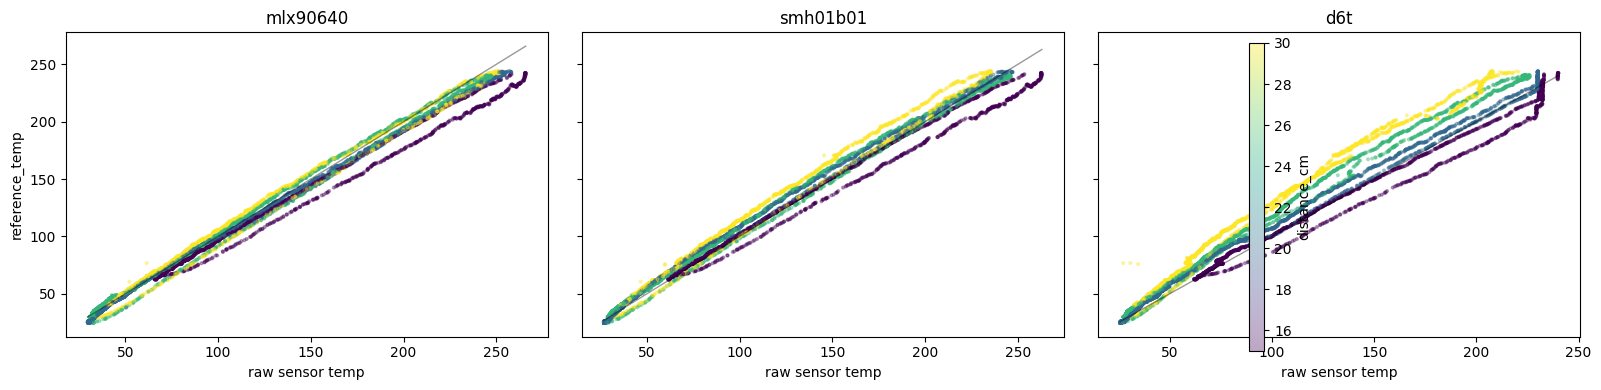

In [7]:
# Quick plots: reference temperature vs each sensor raw value.
plot_df = df.sample(min(len(df), 12000), random_state=7) if len(df) > 12000 else df
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (sensor, col) in zip(axes, SENSORS.items()):
    sc = ax.scatter(plot_df[col], plot_df['reference_temp'], c=plot_df['distance_cm'], s=4, alpha=0.35, cmap='viridis')
    ax.plot([plot_df[col].min(), plot_df[col].max()], [plot_df[col].min(), plot_df[col].max()], color='black', lw=1, alpha=0.4)
    ax.set_title(sensor)
    ax.set_xlabel('raw sensor temp')
axes[0].set_ylabel('reference_temp')
fig.colorbar(sc, ax=axes, label='distance_cm')
plt.tight_layout()

diff_mlx90640                         diff_smh01b01  \
                               mean       std    min    max          mean   
distance_cm direction                                                       
15          down           5.200987  2.994220 -33.29  17.88     -0.378705   
            up            22.583070  5.885264   4.10  31.55     17.528774   
20          down           3.165039  2.467042 -90.57  15.00     -1.540177   
            up             8.133557  2.930671  -1.72  14.00     -2.273470   
25          down          -1.234436  1.907691  -6.28   5.04     -4.758986   
            up             6.781382  2.060392   2.54  12.30      3.096201   
30          down          -2.696108  2.620675 -46.46   7.80     -9.824279   
            up             8.486742  1.453261   4.25  14.53     -2.185078   

                                              diff_d6t                         
                            std   min   max       mean        std   min   max  
distance_cm direction                                                          
15          down       2.774351  -3.2  12.6  -0.232518   3.726796  -8.3  11.3  
            up         6.784980  -0.9  28.1  13.928774   8.287490  -4.6  25.8  
20          down       4.189087 -10.7   4.0  -2.850367   4.509885 -14.3   2.0  
            up         2.383041 -10.3   3.0  -2.405468   3.533506 -12.9   2.4  
25          down       2.834731 -12.6   2.1 -10.931652   7.365875 -28.6  -0.9  
            up         1.806022  -3.1   7.3 -13.240098   5.818094 -23.4   4.0  
30          down       4.926102 -25.3  -2.3 -19.279843  10.243571 -49.5  -5.3  
            up         3.632996 -10.9   5.9 -24.416562  12.664772 -42.5   2.4

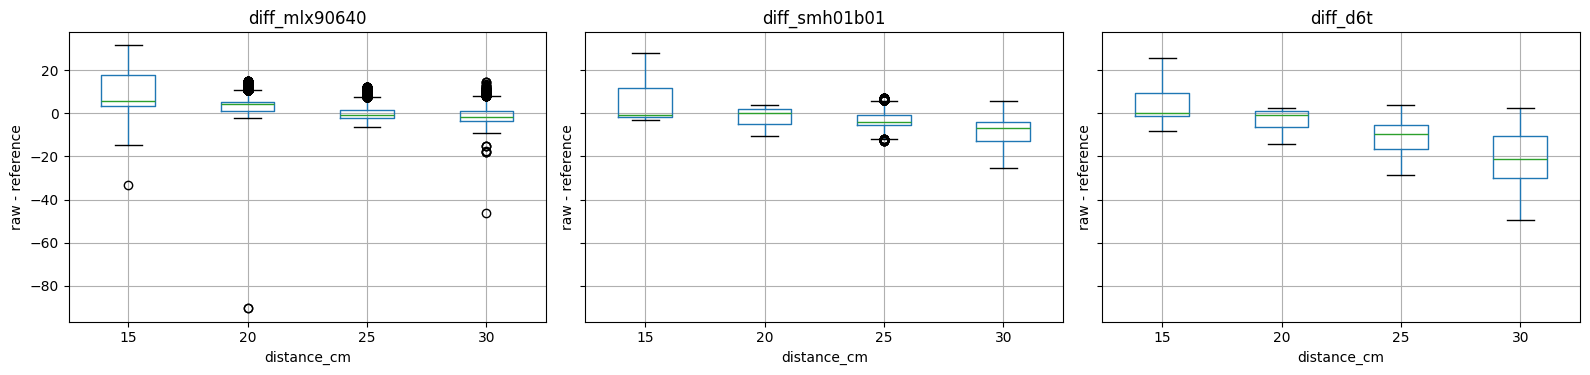

In [8]:
# Raw differences against reference.
df['diff_mlx90640'] = df['mlx90640_max'] - df['reference_temp']
df['diff_smh01b01'] = df['smh01b01_max'] - df['reference_temp']
df['diff_d6t'] = df['d6t_raw'] - df['reference_temp']

diff_summary = df.groupby(['distance_cm', 'direction'])[['diff_mlx90640', 'diff_smh01b01', 'diff_d6t']].agg(['mean', 'std', 'min', 'max'])
display(diff_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, diff_col in zip(axes, ['diff_mlx90640', 'diff_smh01b01', 'diff_d6t']):
    df.boxplot(column=diff_col, by='distance_cm', ax=ax)
    ax.set_title(diff_col)
    ax.set_xlabel('distance_cm')
    ax.set_ylabel('raw - reference')
plt.suptitle('')
plt.tight_layout()

In [12]:
MODEL_SPECS = [
    ('linear_raw', 1, ['raw']),
    ('poly2_raw', 2, ['raw']),
    ('poly3_raw', 3, ['raw']),
    ('poly2_raw_distance', 2, ['raw', 'distance_cm']),
    ('poly3_raw_distance', 3, ['raw', 'distance_cm']),
    ('poly2_raw_distance_direction', 2, ['raw', 'distance_cm', 'direction_code']),
]


def feature_frame(data: pd.DataFrame, raw_col: str, features: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=data.index)
    for feature in features:
        out[feature] = data[raw_col] if feature == 'raw' else data[feature]
    return out


def deterministic_holdout(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Keep the split deterministic and represented per file/time series.
    order = data.groupby('source_path').cumcount()
    test_mask = order.mod(5).eq(0)
    return data.loc[~test_mask].copy(), data.loc[test_mask].copy()


def evaluate_model(sensor: str, raw_col: str, name: str, degree: int, features: list[str]) -> tuple[dict, Pipeline]:
    clean = df.dropna(subset=['reference_temp', raw_col, 'distance_cm', 'direction_code']).copy()
    train, test = deterministic_holdout(clean)
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('linear', LinearRegression(fit_intercept=False)),
    ])
    model.fit(feature_frame(train, raw_col, features), train['reference_temp'])
    pred = model.predict(feature_frame(test, raw_col, features))
    eval_df = test[['reference_temp', 'distance_cm', 'direction']].copy()
    eval_df['pred'] = pred
    by_distance = {
        int(distance): float(mean_absolute_error(group['reference_temp'], group['pred']))
        for distance, group in eval_df.groupby('distance_cm')
    }
    row = {
        'sensor': sensor,
        'model': name,
        'degree': degree,
        'features': features,
        'MAE': float(mean_absolute_error(test['reference_temp'], pred)),
        'RMSE': float(np.sqrt(mean_squared_error(test['reference_temp'], pred))),
        'R2': float(r2_score(test['reference_temp'], pred)),
        'MAE_up': float(mean_absolute_error(eval_df.loc[eval_df['direction'].eq('up'), 'reference_temp'], eval_df.loc[eval_df['direction'].eq('up'), 'pred'])),
        'MAE_down': float(mean_absolute_error(eval_df.loc[eval_df['direction'].eq('down'), 'reference_temp'], eval_df.loc[eval_df['direction'].eq('down'), 'pred'])),
        'MAE_by_distance': by_distance,
        'distance_mae_span': float(max(by_distance.values()) - min(by_distance.values())),
        'n_coefficients': int(len(model.named_steps['linear'].coef_)),
    }
    row['selection_score'] = row['RMSE'] + 0.15 * row['distance_mae_span'] + 0.002 * row['n_coefficients']
    return row, model


rows = []
trained = {}
for sensor, raw_col in SENSORS.items():
    for name, degree, features in MODEL_SPECS:
        row, model = evaluate_model(sensor, raw_col, name, degree, features)
        rows.append(row)
        trained[(sensor, name)] = model

results = pd.DataFrame(rows).sort_values(['sensor', 'selection_score'])
display(results[['sensor', 'model', 'MAE', 'RMSE', 'R2', 'MAE_up', 'MAE_down', 'distance_mae_span', 'n_coefficients', 'selection_score']])

,sensor,model,MAE,RMSE,R2,MAE_up,MAE_down,distance_mae_span,n_coefficients,selection_score
17,d6t,poly2_raw_distance_direction,2.279674,3.536179,0.997092,5.115554,1.713100,3.504268,10,4.081819
15,d6t,poly2_raw_distance,2.683619,4.273443,0.995753,7.153666,1.790559,3.573656,6,4.821492
16,d6t,poly3_raw_distance,2.922855,4.238773,0.995822,6.582043,2.191795,5.726196,10,5.117703
14,d6t,poly3_raw,6.676609,9.394122,0.979479,12.684956,5.476216,11.218012,4,11.084824
13,d6t,poly2_raw,6.241062,9.229776,0.980191,12.783626,4.933938,12.873458,3,11.166795
12,d6t,linear_raw,7.524826,10.490023,0.974412,13.630242,6.305039,9.299546,2,11.888954
5,mlx90640,poly2_raw_distance_direction,1.766506,2.224324,0.998850,3.387723,1.442606,1.070279,10,2.404866
3,mlx90640,poly2_raw_distance,2.600067,3.583458,0.997014,5.967554,1.927285,3.536229,6,4.125892
4,mlx90640,poly3_raw_distance,3.224335,4.433226,0.995430,6.202390,2.629356,4.993787,10,5.202294
2,mlx90640,poly3_raw,3.717494,4.918852,0.994374,7.074125,3.046880,3.732255,4,5.486690


In [13]:
def choose_best(group: pd.DataFrame) -> pd.Series:
    # Main criterion is low RMSE, with distance stability penalty. Prefer simpler models if close.
    best_rmse = group['RMSE'].min()
    close = group[group['RMSE'].le(best_rmse * 1.02 + 0.05)].copy()
    close = close.sort_values(['n_coefficients', 'selection_score'])
    return close.iloc[0]


selected = results.groupby('sensor', group_keys=False).apply(choose_best).reset_index(drop=True)
display(selected[['sensor', 'model', 'features', 'MAE', 'RMSE', 'R2', 'MAE_up', 'MAE_down', 'MAE_by_distance']])

KeyError: "['sensor'] not in index"

In [11]:
def export_profile(sensor: str, raw_col: str, model_name: str, degree: int, features: list[str]) -> dict:
    clean = df.dropna(subset=['reference_temp', raw_col, 'distance_cm', 'direction_code']).copy()
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('linear', LinearRegression(fit_intercept=False)),
    ])
    X = feature_frame(clean, raw_col, features)
    model.fit(X, clean['reference_temp'])
    poly = model.named_steps['poly']
    linear = model.named_steps['linear']
    return {
        'model_name': model_name,
        'degree': int(degree),
        'features': features,
        'powers': poly.powers_.astype(int).tolist(),
        'coefficients': [float(x) for x in linear.coef_],
        'uses_direction': 'direction_code' in features,
    }


profiles = {}
for _, row in selected.iterrows():
    profiles[row['sensor']] = export_profile(
        row['sensor'],
        SENSORS[row['sensor']],
        row['model'],
        int(row['degree']),
        list(row['features']),
    )

runtime_template = f'''\
"""
Polynomial calibration profiles exported from notebooks/train_calibration.ipynb.

Runtime intentionally depends only on the Python standard library.
"""

from __future__ import annotations

import logging
import math

logger = logging.getLogger("calib")


CALIB_PROFILES = {json.dumps(profiles, indent=4)}


def _direction_code(direction: str | int | float | None) -> float:
    if direction is None:
        return 0.5
    if isinstance(direction, str):
        text = direction.strip().lower()
        if text == "up":
            return 1.0
        if text == "down":
            return 0.0
        logger.warning("[CALIB] unknown direction=%r, using neutral value", direction)
        return 0.5
    try:
        value = float(direction)
    except (TypeError, ValueError):
        logger.warning("[CALIB] invalid direction=%r, using neutral value", direction)
        return 0.5
    return 1.0 if value >= 0.5 else 0.0


def calibrate(sensor_name: str, raw_value: float, distance_cm: int | float | None, direction=None) -> float:
    profile = CALIB_PROFILES.get(sensor_name)
    try:
        raw = float(raw_value)
    except (TypeError, ValueError):
        logger.warning("[CALIB] invalid raw value for sensor=%s, using raw value", sensor_name)
        return raw_value

    if profile is None:
        logger.warning("[CALIB] profile not found, using raw value")
        return raw
    if not math.isfinite(raw):
        return raw

    values = []
    for feature in profile["features"]:
        if feature == "raw":
            values.append(raw)
        elif feature == "distance_cm":
            if distance_cm is None:
                logger.warning("[CALIB] distance_cm missing for sensor=%s, using raw value", sensor_name)
                return raw
            values.append(float(distance_cm))
        elif feature == "direction_code":
            values.append(_direction_code(direction))
        else:
            logger.warning("[CALIB] unknown feature=%s for sensor=%s, using raw value", feature, sensor_name)
            return raw

    result = 0.0
    for coefficient, powers in zip(profile["coefficients"], profile["powers"]):
        term = float(coefficient)
        for value, power in zip(values, powers):
            if power:
                term *= value ** int(power)
        result += term
    return float(result) if math.isfinite(result) else raw
'''

out_path = ROOT / 'src' / 'calib_profiles.py'
out_path.write_text(runtime_template, encoding='utf-8')
print(f'Exported {out_path}')
print(json.dumps(profiles, indent=2))

KeyError: 'sensor'